<a href="https://colab.research.google.com/github/Soham-bit-coder/MACHINE-LEARNING/blob/main/ridge_ipyb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [ ]:
weight=0.7
bias=0.3

start=0
end=1
step=0.02
x=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*x+bias
x[:5],y[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]))

In [ ]:
train_split=int(0.8*len(x))
x_train,y_train=x[:train_split],y[:train_split]
x_test,y_test=x[train_split:],y[train_split:]
len(x_train),len(y_train),len(x_test),len(y_test)

(40, 40, 10, 10)

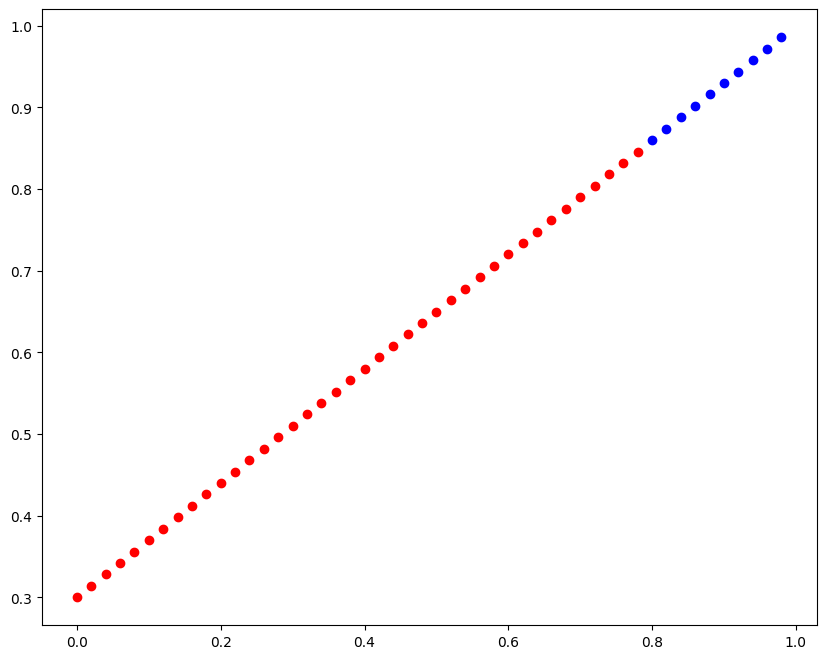

In [ ]:
def  plotprediction(train_data=x_train,
                    train_label=y_train,
                    test_data=x_test,
                    test_label=y_test,
                    prediction=None):

  plt.figure(figsize=(10,8))
  plt.scatter(train_data,train_label,c='r')
  plt.scatter(test_data,test_label,c='b')

  if prediction is not None:
    plt.scatter(test_data,prediction)
  plt.show()

plotprediction()

In [ ]:
class LinearRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight=nn.Parameter(torch.randn(1,
                                          requires_grad=True,
                                          dtype=torch.float))

    self.bias=nn.Parameter(torch.randn(1,
                                       requires_grad=True,
                                       dtype=torch.float))

  def forward(self,x:torch.tensor) -> torch.tensor:
      return self.weight * x + self.bias

model=LinearRegression()
for param in model.parameters():
    print(param)

Parameter containing:
tensor([-0.5844], requires_grad=True)
Parameter containing:
tensor([0.5442], requires_grad=True)


In [ ]:
with torch.inference_mode():
  y_pred=model(x_test)

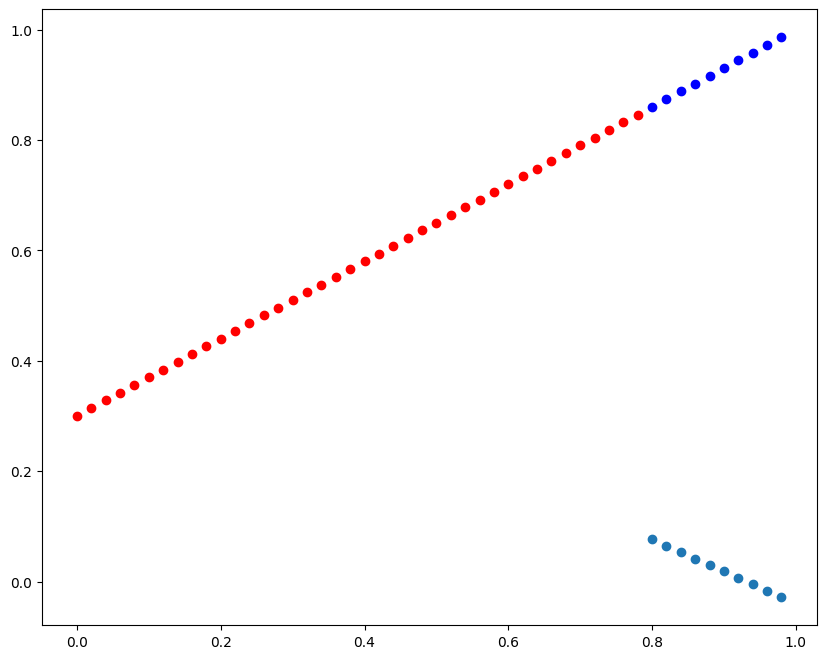

In [ ]:
plotprediction(prediction=y_pred)

In [ ]:
lambda_l1 = 0.1

def lasso_loss(y_pred, y_true, model):
    mse = torch.mean((y_pred - y_true) ** 2)
    l1_penalty = lambda_l1 * torch.sum(torch.abs(model.weight))
    return mse + l1_penalty
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [ ]:
torch.manual_seed(42)

epochs=50  #an epoch is one loop through the data

# 0. looping thorugh data

for epoch in range(epochs):

# 1. set the model to training mode
  model.train()

#  2. forward pass
  y_pred=model(x_train)

# 3. optimizer zero grad
  optimizer.zero_grad()

# 4.perform backpropogation on the loss with respect to the parameter in the model
  loss=lasso_loss(y_pred,y_train,model)
  loss.backward()
  print(f'loss:{loss}')

# 5.step the optimizer
  optimizer.step()

###### testing
  model.eval()    # truns off different things not needed for the model for evaluating/testing (dropout/batch norm layers)

model.state_dict()

loss:0.026568377390503883
loss:0.026470836251974106
loss:0.026389015838503838
loss:0.02631690353155136
loss:0.026250967755913734
loss:0.02618909627199173
loss:0.02613004669547081
loss:0.026490136981010437
loss:0.026547318324446678
loss:0.026450425386428833
loss:0.0263691283762455
loss:0.026297476142644882
loss:0.026231948286294937
loss:0.026170458644628525
loss:0.02620447427034378
loss:0.026592863723635674
loss:0.026492657139897346
loss:0.026409126818180084
loss:0.026335882022976875
loss:0.02626913972198963
loss:0.026206670328974724
loss:0.026147140190005302
loss:0.026372738182544708
loss:0.026565423235297203
loss:0.026467934250831604
loss:0.026386167854070663
loss:0.026314107701182365
loss:0.02624821849167347
loss:0.026186401024460793
loss:0.026127401739358902
loss:0.02650809846818447
loss:0.026544583961367607
loss:0.026447739452123642
loss:0.026366490870714188
loss:0.02629489079117775
loss:0.026229407638311386
loss:0.026167960837483406
loss:0.026221295818686485
loss:0.026590283960103

OrderedDict([('weight', tensor([0.0050])), ('bias', tensor([0.5697]))])

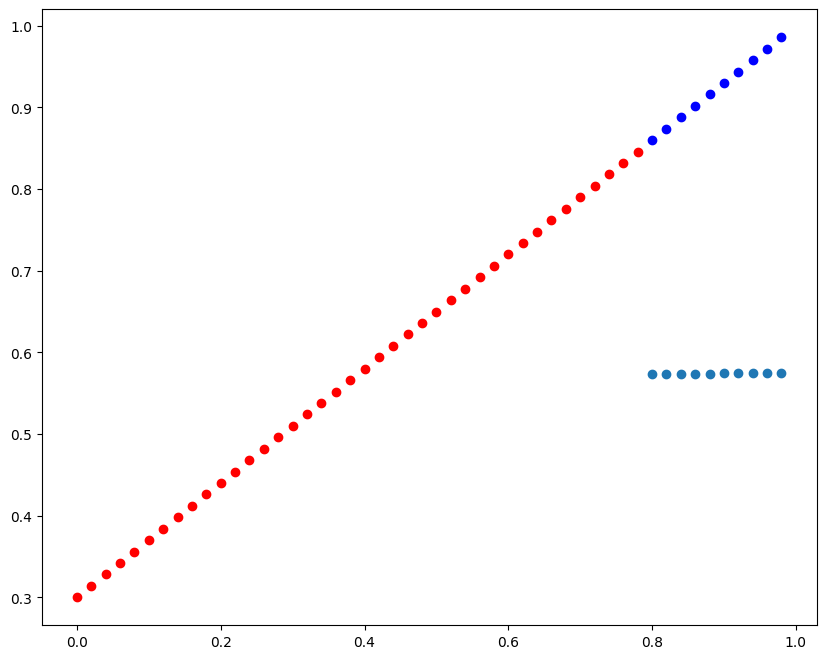

In [ ]:
with torch.inference_mode():
  new_y_pred=model(x_test)

plotprediction(prediction=new_y_pred)